In [51]:
import pandas as pd
from scanpy import read_h5ad
import seaborn as sns

In [52]:
df = pd.read_csv('/home/lnemati/pathway_crosstalk/data/thorsson_immune_landscape_2018.csv')
df = df[['TCGA Participant Barcode', 'TCGA Study', 'TCGA Subtype']]
df.columns = ['barcode', 'tissue', 'subtype']
df['barcode'] = df['barcode'].astype(str) + '-01'
df = df.dropna()

In [53]:
import pandas as pd
from scanpy import read_h5ad

tcga = read_h5ad('/projects/bioinformatics/DB/Xena/TCGA_GTEX/all_merged_tcga_vs_gtex/tcga_scaled.h5ad')
tcga.obs_names.intersection(df['barcode'])

df_map = df.set_index('barcode')
tcga.obs['subtype'] = tcga.obs_names.map(df_map['subtype'])
tcga.obs['tissue'] = tcga.obs_names.map(df_map['tissue'])

ccc = pd.read_csv('/home/lnemati/pathway_crosstalk/data/interactions/ccc_lr_pairs.csv')
ccc_genes = list(set(ccc['ligand']).union(ccc['receptor']))
ccc_genes = [g for g in ccc_genes if g in tcga.var_names]

tcga_sub = tcga[:, ccc_genes].copy()

In [54]:
X = tcga_sub.X.toarray() if hasattr(tcga_sub.X, "toarray") else tcga_sub.X

expr = pd.DataFrame(
    X,
    index=tcga_sub.obs_names,
    columns=tcga_sub.var_names
)

expr['subtype'] = tcga_sub.obs['subtype'].values
expr['tissue'] = tcga_sub.obs['tissue'].values

In [56]:
pairs = ccc[['ligand', 'receptor']].drop_duplicates()

subtypes = expr['subtype'].unique()

out = {}

for st in subtypes:
    sub = expr[expr['subtype'] == st].drop(columns=['subtype', 'tissue'])

    if sub.shape[0] < 10:
        continue

    corr_dict = {}

    for lig, rec in pairs.itertuples(index=False):
        if lig in sub.columns and rec in sub.columns:
            corr_dict[f"{lig}+{rec}"] = sub[lig].corr(sub[rec])

    out[st] = corr_dict
    
df_corr = pd.DataFrame.from_dict(out, orient='index')
df_corr.index.name = 'subtype'

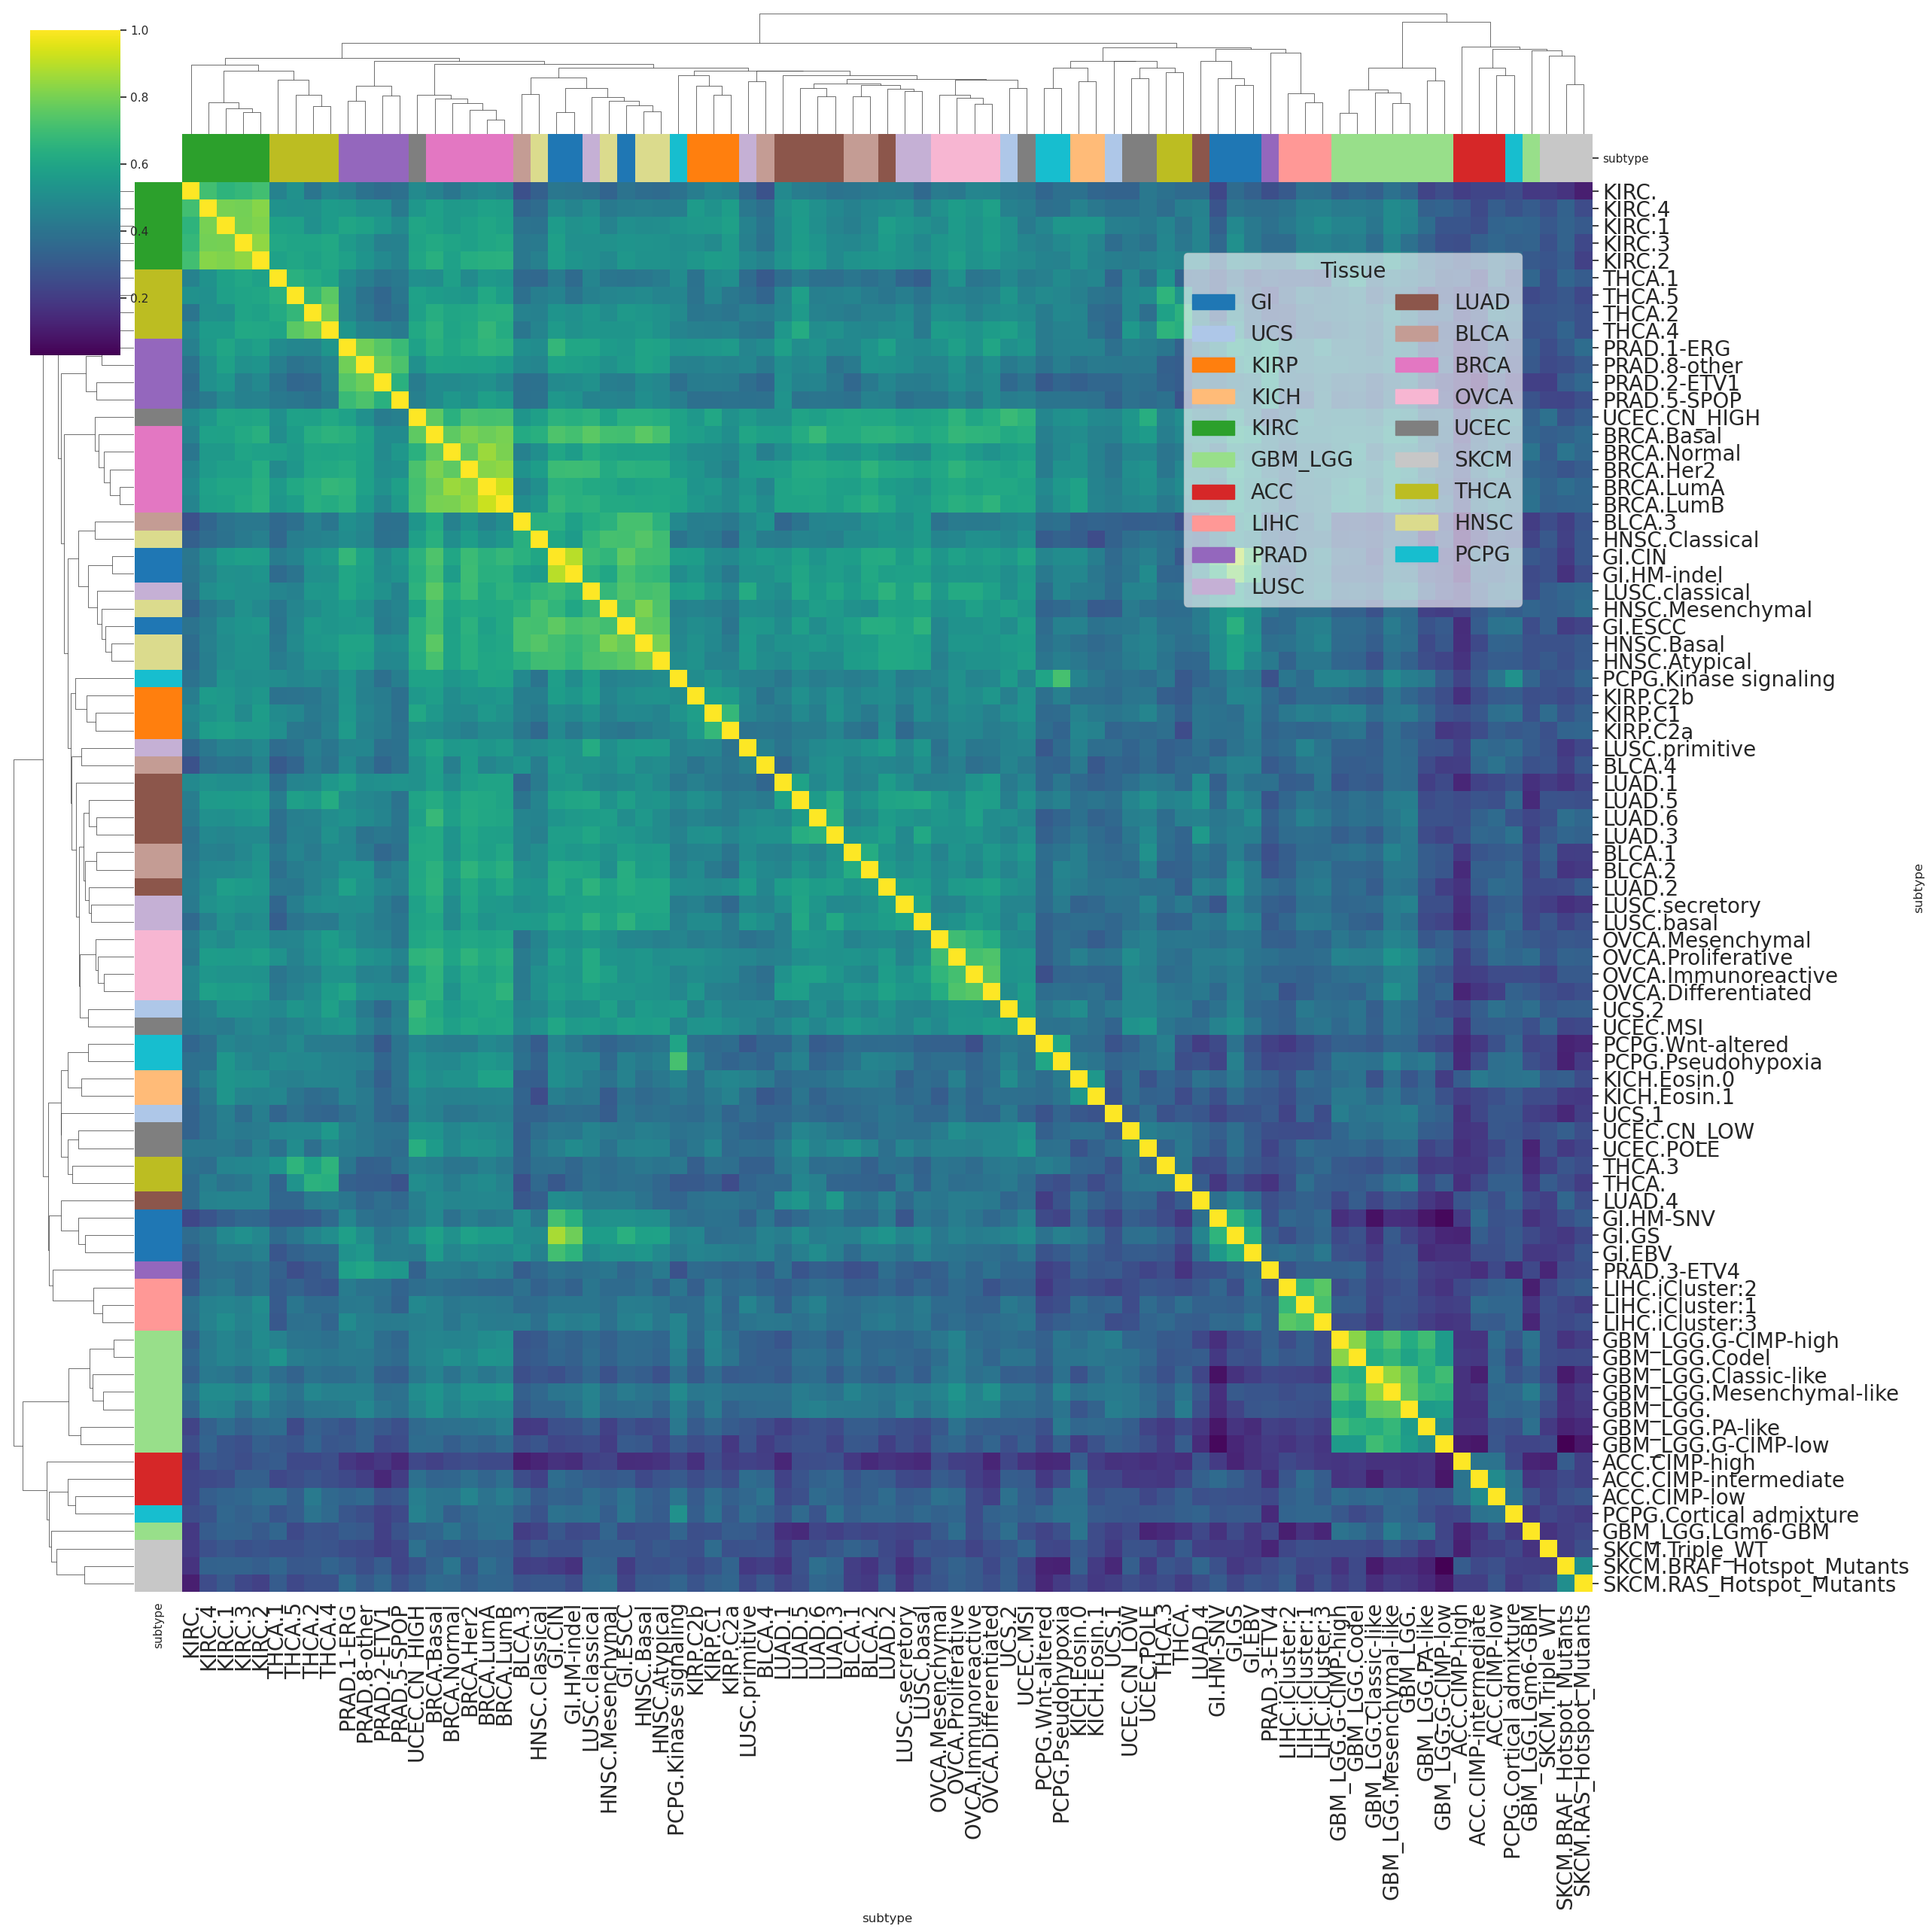

In [133]:
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt
# subtype x subtype correlation
df_subtype_sim = df_corr.T.corr(method='pearson')
# extract prefix before first "."
tissue = df_subtype_sim.index.to_series().str.split(".").str[0]

# assign a color per tissue
palette = sns.color_palette("tab20", len(tissue.unique()))
tissue_lut = dict(zip(tissue.unique(), palette))

row_colors = tissue.map(tissue_lut)
col_colors = row_colors  # same order since matrix is symmetric

row_linkage = linkage(df_subtype_sim, method="average")

g = sns.clustermap(
    df_subtype_sim,
    row_linkage=row_linkage,
    col_linkage=row_linkage,
    cmap="viridis",
    figsize=(24, 24),
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.08, 0.08)
)

import matplotlib.patches as mpatches
fs=20

handles = [
    mpatches.Patch(color=tissue_lut[t], label=t)
    for t in tissue.unique()
]
leg = g.ax_heatmap.legend(
    handles=handles,
    title="Tissue",
    bbox_to_anchor=(0.95, 0.95),
    loc="upper right",
    framealpha=0.6,
    borderaxespad=0,
    fontsize=fs,
    ncol=2
)
leg.set_title("Tissue", prop={'size': fs})

g.ax_heatmap.tick_params(axis='x', labelsize=fs)
g.ax_heatmap.tick_params(axis='y', labelsize=fs)

plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/molecular_subtype_clustermap.pdf', dpi=300, bbox_inches='tight')
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/molecular_subtype_clustermap.png', dpi=300, bbox_inches='tight')

plt.show()

/home/lnemati/.conda/envs/new_cci_paper/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/lnemati/.conda/envs/new_cci_paper/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


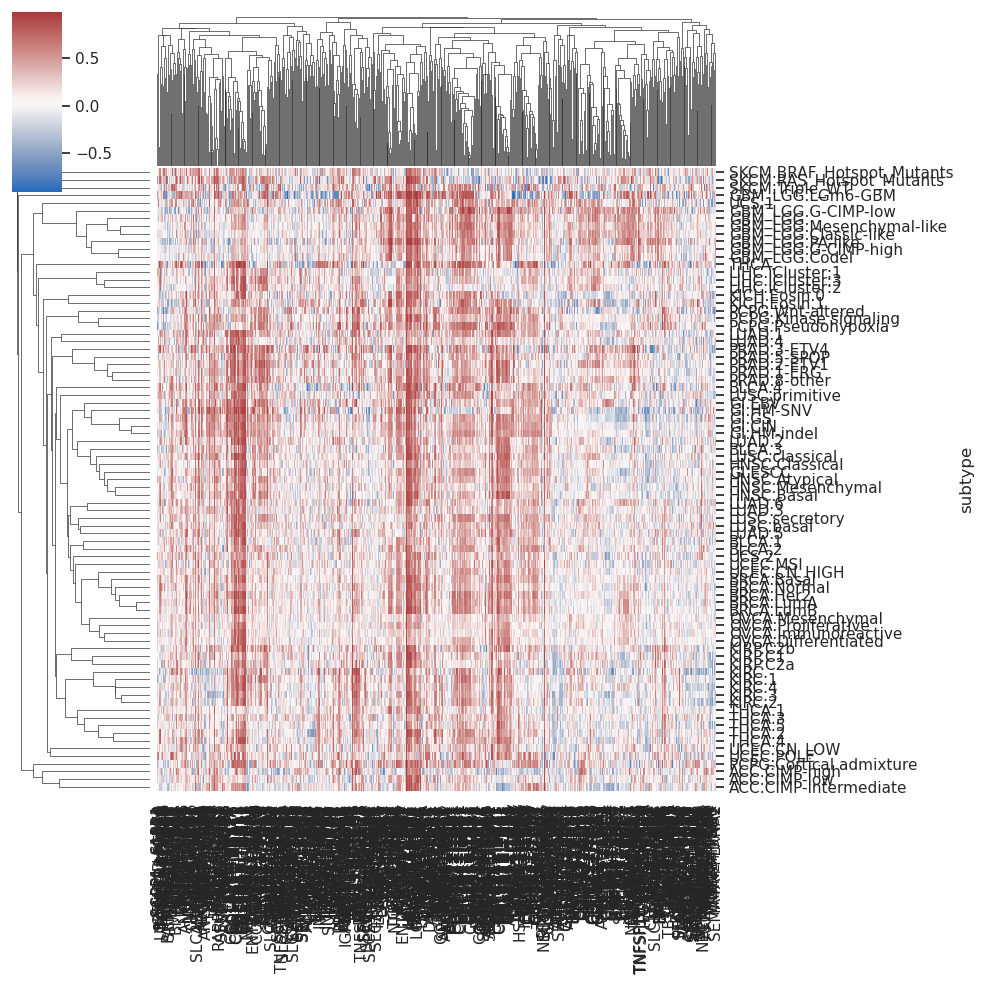

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="white")

g = sns.clustermap(
    df_corr.fillna(0),
    cmap="vlag",
    metric="correlation",   # key: compares patterns
    method="average",
    figsize=(10, 10),
    xticklabels=False,
    yticklabels=True
)

plt.show()

In [58]:
df_corr

,CADM1+NECTIN3,COL12A1+ITGA1,COL12A1+ITGB1,COL12A1+ITGA11,COL14A1+ITGA1,COL14A1+ITGB1,COL14A1+ITGA11,COL15A1+ITGA1,COL15A1+ITGB1,COL15A1+ITGA11,...,SEMA4A+PLXNA3,SEMA5A+PLXNA1,SEMA5A+PLXNA3,SEMA6B+PLXNA2,LAMA3+ITGA1,LAMA4+ITGA1,LAMA5+ITGA1,LAMB1+ITGA1,LAMB2+ITGA1,LAMC1+ITGA1
subtype,,,,,,,,,,,,,,,,,,,,,
GI.CIN,-0.228630,0.603351,0.483581,0.837298,0.653101,0.383899,0.690082,0.659524,0.384283,0.582991,...,-0.058570,-0.018837,-0.002095,0.058984,0.018022,0.760101,0.043560,0.445696,0.422203,0.551422
GI.GS,0.082196,0.576668,0.472665,0.739952,0.647089,0.343823,0.506496,0.684299,0.499770,0.586043,...,0.059998,0.146596,-0.206709,0.028561,-0.175143,0.799415,0.435065,0.264192,0.665898,0.712969
GI.HM-indel,-0.078795,0.535930,0.628636,0.809786,0.587787,0.471134,0.639023,0.544643,0.553828,0.616125,...,0.021045,0.076277,-0.009329,0.090013,0.113917,0.696483,0.120698,0.522826,0.237789,0.651036
GI.HM-SNV,-0.070739,0.198387,-0.304094,0.968458,0.276524,-0.242706,0.425171,0.336886,0.017689,0.581958,...,-0.149649,-0.108023,-0.078336,0.027324,-0.065168,0.394427,-0.181427,0.189583,0.339044,0.387642
UCS.1,0.004322,0.151458,0.305966,0.507371,0.454205,0.618426,0.403867,0.727923,0.591443,0.510286,...,-0.007915,0.351450,0.067981,0.497128,0.229496,0.274794,0.208021,0.677061,0.279762,0.485335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PCPG.Wnt-altered,-0.025870,0.559542,0.544584,0.194611,0.333543,0.376017,0.394825,0.633193,0.621496,0.260866,...,0.134431,0.094827,-0.235808,0.138534,0.125902,0.821844,0.525978,0.652140,0.210093,0.776808
PCPG.Pseudohypoxia,0.545809,0.769062,0.677461,0.128226,0.560039,0.660463,0.304632,0.753272,0.597587,0.007288,...,-0.149741,0.060761,-0.188690,-0.179274,0.028164,0.873845,0.775207,0.819274,0.566304,0.847609
PCPG.Cortical admixture,0.064227,0.196271,0.510240,0.612673,0.235040,0.374298,0.696217,0.586386,0.037083,0.518597,...,0.044875,0.104227,0.348420,-0.197634,-0.320500,-0.198465,0.599915,0.487669,0.603975,0.095503


In [22]:


import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("tab20", tissues.nunique())
tissue_lut = dict(zip(tissues.unique(), palette))

row_colors = tissues.map(tissue_lut)
row_colors = row_colors.fillna((0.8, 0.8, 0.8))  # gray fallback

col_colors = pd.Series(
    "#dddddd",
    index=df_corr.columns
)

sns.set(style="white")

g = sns.clustermap(
    df_corr.fillna(0),
    cmap="vlag",
    figsize=(14, 10),
    row_colors=row_colors,
    col_colors=col_colors,
    linewidths=0,
    xticklabels=False,
    yticklabels=True
)

plt.show()

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

NameError: name 'tissues' is not defined

In [ ]:
df_corr.index.is_unique

In [85]:
df_corr.columns

Index(['CADM1+NECTIN3', 'COL12A1+ITGA1', 'COL12A1+ITGB1', 'COL12A1+ITGA11',
       'COL14A1+ITGA1', 'COL14A1+ITGB1', 'COL14A1+ITGA11', 'COL15A1+ITGA1',
       'COL15A1+ITGB1', 'COL15A1+ITGA11',
       ...
       'SEMA4A+PLXNA3', 'SEMA5A+PLXNA1', 'SEMA5A+PLXNA3', 'SEMA6B+PLXNA2',
       'LAMA3+ITGA1', 'LAMA4+ITGA1', 'LAMA5+ITGA1', 'LAMB1+ITGA1',
       'LAMB2+ITGA1', 'LAMC1+ITGA1'],
      dtype='str', length=600)

In [79]:
tissues = subtype_to_tissue.loc[df_corr.index]

palette = sns.color_palette("tab20", len(tissues.unique()))
tissue_lut = dict(zip(tissues.unique(), palette))

row_colors = tissues.map(tissue_lut)

col_colors = pd.Series(
    ["#dddddd"] * df_corr.shape[1],
    index=df_corr.columns
)

sns.set(style="white")

g = sns.clustermap(
    df_corr.fillna(0),
    cmap="vlag",
    figsize=(14, 10),
    row_colors=row_colors,
    col_colors=col_colors,
    linewidths=0,
    xticklabels=False,
    yticklabels=True
)

plt.show()

ValueError: cannot reindex on an axis with duplicate labels

<Figure size 1400x1000 with 0 Axes>